# Analysis of mirror codes
This is a high-level wrapper of the mirror code and benchmarking functionalities of this repository, enabling benchmarking of a chosen mirror code.

In [1]:
from mirror import MirrorCode
from benchmark import StabilizerCode, make_noise_model
import numpy as np
import matplotlib.pyplot as plt
import stim
import sinter
from tesseract_decoder import make_tesseract_sinter_decoders_dict, TesseractSinterDecoder
import tesseract_decoder

As an example, let us benchmark the `[[n, k, d, w]] = [[36, 6, 6, 6]]` code.

In [2]:
# [[36, 6, 6, 6]] code
# code = MirrorCode(
#         group = [2, 2, 3, 3],
#         z0 = [[0, 0, 0, 0],
#        [0, 1, 0, 1],
#        [1, 0, 0, 2]],
#         x0 = [[0, 0, 0, 0],
#        [0, 1, 1, 0],
#        [1, 1, 2, 0]]
#     )

# CODE_NAME = "[[36, 6, 6]]"

code = MirrorCode(group=[2, 6, 6],
                  z0 = [[0, 0, 0],
                        [0, 0, 1]],
                  x0 = [[1, 0, 0],
                       [1, 1, 0]])
CODE_NAME = "Toric"

NOISE_MODEL_NAME = "SI1000"

Finding stabilizers...
Done.
Making syndrome extraction circuits...
Done


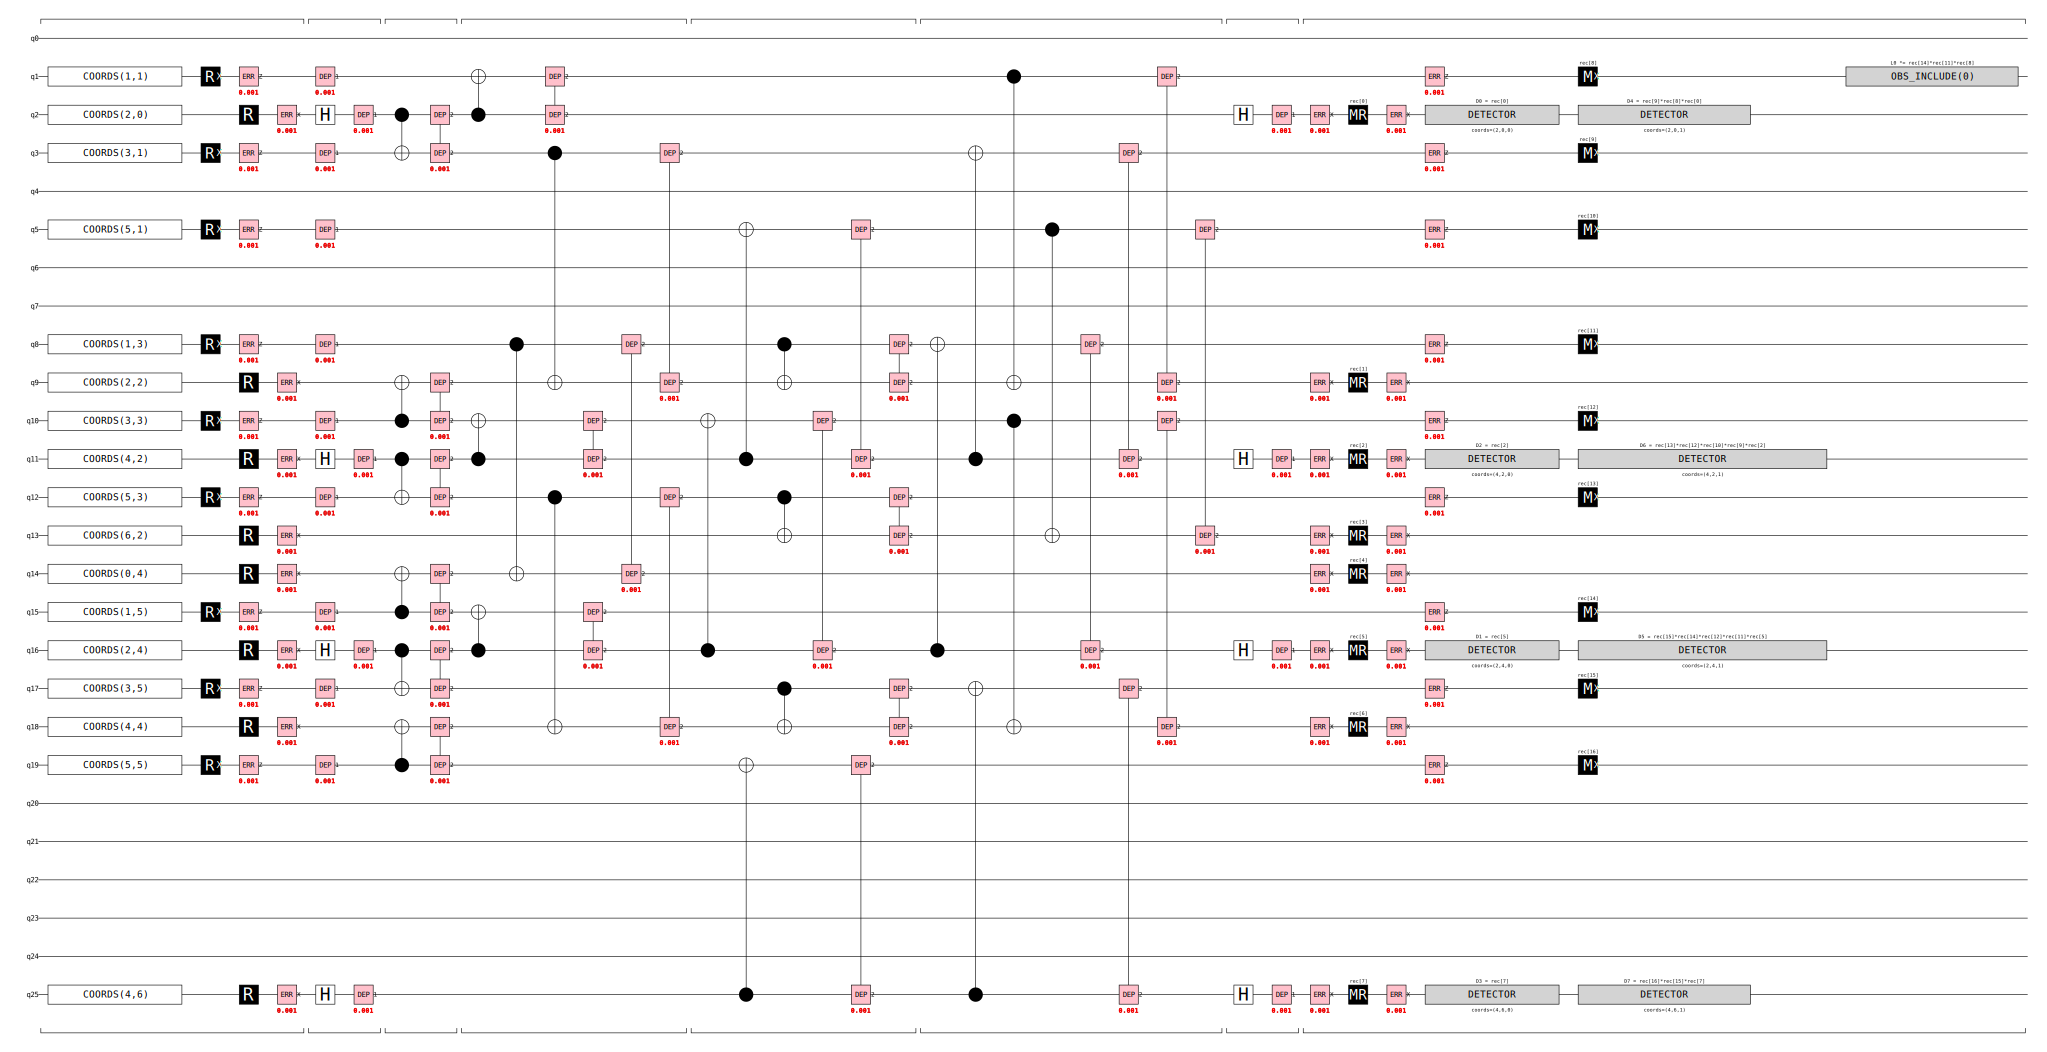

In [9]:
print("Finding stabilizers...")
stabilizers = code.get_stim_tableau()
print("Done.")

benchmarker = StabilizerCode(stabilizers, verbose=False, name=CODE_NAME)

T = 6 # min error rate is 10^-T
NUM_PROBS = 8

# Define the main parameters of the benchmarking
ROUND_CHOICES = [3, 6, 9]
PS = np.logspace(-T, -2, NUM_PROBS)
NUM_SHOTS = 100_000

print("Making syndrome extraction circuits...")
# SECS = [code.bare_ancilla_sec(noise=make_noise_model( NOISE_MODEL_NAME, PS[i]),
#                               num_rounds=nrd
#                               )
#                             for nrd in ROUND_CHOICES
#                             for i in range(len(PS))
#         ]
 
p=0.001
SEC = stim.Circuit.generated(
            code_task="surface_code:rotated_memory_x",
            distance=3,
            rounds=1,
            after_clifford_depolarization=p,
            before_round_data_depolarization=p,
            before_measure_flip_probability=p,
            after_reset_flip_probability=p
        )
print("Done")

SEC.diagram(type='timeline-svg')

In [8]:
sinter_stats = benchmarker.parallel_benchmark(ps=PS,
                               secs=SECS,
                               rounds_choices=ROUND_CHOICES,
                               num_shots=NUM_SHOTS,
                               plot=True
                               )

Process SpawnPoolWorker-26:
Process SpawnPoolWorker-22:
Process SpawnPoolWorker-28:
Process SpawnPoolWorker-27:
Process SpawnPoolWorker-24:
Process SpawnPoolWorker-25:
Process SpawnPoolWorker-21:
Process SpawnPoolWorker-19:
Process SpawnPoolWorker-17:
Process SpawnPoolWorker-15:
Process SpawnPoolWorker-23:
Process SpawnPoolWorker-18:


KeyboardInterrupt: 